# map_processor debug notebook

This notebook mirrors `map_processor.py`, but keeps every important intermediate image visible: raw map loading, thresholding, dilation, template scaling, wall matching, alignment, per-object match heatmaps, masking, and final output canvases.

Run cells top to bottom. The default paths assume this notebook lives in `scan_map/scripts/` and reads `../maps/raw_map.pgm` plus `../templates/*.png`.

In [100]:
from pathlib import Path
import csv

import cv2
import matplotlib.pyplot as plt
import numpy as np
import yaml

plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['image.cmap'] = 'gray'

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / '../maps/raw_map.pgm').resolve().exists():
    # Allows running from repo root in JupyterLab.
    NOTEBOOK_DIR = Path('scan_map/scripts').resolve()

MAP_DIR = (NOTEBOOK_DIR / '../maps').resolve()
TPL_DIR = (NOTEBOOK_DIR / '../templates').resolve()
RAW_MAP = MAP_DIR / 'raw_map.pgm'

TPL_RES = 0.001
FINAL_RES = 0.01
FIELD_SIZE = 4.0

print('MAP_DIR =', MAP_DIR)
print('TPL_DIR =', TPL_DIR)
print('RAW_MAP =', RAW_MAP)

MAP_DIR = /home/samuel/wildbot/scan_map/maps
TPL_DIR = /home/samuel/wildbot/scan_map/templates
RAW_MAP = /home/samuel/wildbot/scan_map/maps/raw_map.pgm


## Helpers

These are copied from the processor, with extra debug helpers for plotting score maps and overlays.

In [ ]:
def show_img(img, title='', cmap='gray', vmin=None, vmax=None, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.axis('off')
    return ax


def show_grid(items, cols=3, figsize_per=(5, 5), cmap='gray'):
    rows = int(np.ceil(len(items) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(figsize_per[0] * cols, figsize_per[1] * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, item in zip(axes, items):
        title, img = item[:2]
        kwargs = item[2] if len(item) > 2 else {}
        show_img(img, title, cmap=kwargs.get('cmap', cmap), vmin=kwargs.get('vmin'), vmax=kwargs.get('vmax'), ax=ax)
    for ax in axes[len(items):]:
        ax.axis('off')
    fig.tight_layout()
    return fig


def load_scaled_template(filename, target_res, threshold=200, crop=True):
    """Load template PNG as a white obstacle mask.

    Template files are black obstacle geometry on white background. For overlays
    and final drawing, ignore all white background pixels and keep only black
    geometry as 255-valued mask pixels.
    """
    img = cv2.imread(str(TPL_DIR / filename), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Missing template: {filename}')
    if img.shape[0] == 0 or img.shape[1] == 0:
        return None
    img = np.where(img < threshold, 255, 0).astype(np.uint8)
    if int(np.max(img)) == 0:
        return None
    if crop:
        ys, xs = np.where(img > 0)
        img = img[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    scale = TPL_RES / target_res
    w = max(1, int(round(img.shape[1] * scale)))
    h = max(1, int(round(img.shape[0] * scale)))
    return cv2.resize(img, (w, h), interpolation=cv2.INTER_NEAREST)


def create_wall_template(size=FIELD_SIZE, thickness=0.1, res=FINAL_RES):
    p_size, p_thick = int(size / res), int(thickness / res)
    img = np.zeros((p_size + p_thick * 2, p_size + p_thick * 2), dtype=np.uint8)
    cv2.rectangle(img, (p_thick, p_thick), (p_size + p_thick, p_size + p_thick), 255, p_thick)
    return img


def rotate_template(template, angle):
    h, w = template.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(template, M, (w, h), flags=cv2.INTER_NEAREST)


def rotate_template_bound(template, angle):
    """Rotate a mask without clipping its corners."""
    h, w = template.shape
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int(np.ceil((h * sin) + (w * cos)))
    new_h = int(np.ceil((h * cos) + (w * sin)))
    M[0, 2] += (new_w / 2.0) - center[0]
    M[1, 2] += (new_h / 2.0) - center[1]
    return cv2.warpAffine(template, M, (new_w, new_h), flags=cv2.INTER_NEAREST, borderValue=0)


def fit_template_overlap_debug(map_img, template, angles, scales=(1.0,)):
    """Sparse occupied-pixel overlap matcher.

    Score is overlap / template_pixels. This ignores white/free areas entirely,
    which is usually more stable for sparse lidar returns than CCOEFF.
    """
    map01 = (map_img > 0).astype(np.float32)
    best = {'score': -np.inf, 'loc': (0, 0), 'angle': None, 'scale': None, 'rotated': None, 'response': None}
    per_trial = []
    for scale in scales:
        if scale == 1.0:
            scaled = template
        else:
            sw = max(1, int(round(template.shape[1] * scale)))
            sh = max(1, int(round(template.shape[0] * scale)))
            scaled = cv2.resize(template, (sw, sh), interpolation=cv2.INTER_NEAREST)
        for angle in angles:
            rotated = rotate_template_bound(scaled, angle)
            rot01 = (rotated > 0).astype(np.float32)
            denom = float(rot01.sum())
            if denom == 0 or rotated.shape[0] > map_img.shape[0] or rotated.shape[1] > map_img.shape[1]:
                continue
            response = cv2.matchTemplate(map01, rot01, cv2.TM_CCORR) / denom
            _, score, _, loc = cv2.minMaxLoc(response)
            per_trial.append((scale, angle, score))
            if score > best['score']:
                best.update(score=score, loc=loc, angle=angle, scale=scale, rotated=rotated, response=response)
    if best['rotated'] is None:
        best['cx'] = 0
        best['cy'] = 0
        best['per_trial'] = np.array(per_trial, dtype=float)
        return best
    h, w = best['rotated'].shape
    best['cx'] = best['loc'][0] + w // 2
    best['cy'] = best['loc'][1] + h // 2
    best['per_trial'] = np.array(per_trial, dtype=float)
    return best


def fit_template_debug(map_img, template, angles, method=cv2.TM_CCOEFF_NORMED):
    best = {
        'score': -np.inf,
        'loc': (0, 0),
        'angle': None,
        'rotated': None,
        'response': None,
    }
    per_angle = []
    h, w = template.shape
    for angle in angles:
        rotated = rotate_template(template, angle)
        response = cv2.matchTemplate(map_img, rotated, method)
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(response)
        if method in (cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED):
            score, loc = -min_val, min_loc
        else:
            score, loc = max_val, max_loc
        per_angle.append((angle, score))
        if score > best['score']:
            best.update(score=score, loc=loc, angle=angle, rotated=rotated, response=response)
    best['cx'] = best['loc'][0] + w // 2
    best['cy'] = best['loc'][1] + h // 2
    best['per_angle'] = np.array(per_angle, dtype=float)
    return best


def overlay_template(map_img, template, cx, cy, title='overlay'):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(map_img, cmap='gray', vmin=0, vmax=255)
    h, w = template.shape
    extent = [cx - w // 2, cx - w // 2 + w, cy - h // 2 + h, cy - h // 2]
    masked = np.ma.masked_where(template <= 0, template)
    ax.imshow(masked, cmap='autumn', alpha=0.55, extent=extent, interpolation='nearest')
    ax.plot(cx, cy, 'c+', markersize=14, markeredgewidth=2)
    ax.set_title(title)
    ax.axis('off')
    return fig


def draw_on_map(canvas, template, cx, cy, yaw):
    if template is None:
        return
    rotated = rotate_template_bound(template, yaw)
    h, w = rotated.shape
    y1, y2 = max(0, cy - h // 2), min(canvas.shape[0], cy + h // 2 + h % 2)
    x1, x2 = max(0, cx - w // 2), min(canvas.shape[1], cx + w // 2 + w % 2)
    ry1, ry2 = max(0, h // 2 - cy), h - max(0, cy + h // 2 + h % 2 - canvas.shape[0])
    rx1, rx2 = max(0, w // 2 - cx), w - max(0, cx + w // 2 + w % 2 - canvas.shape[1])
    mask = rotated[ry1:ry2, rx1:rx2]
    canvas[y1:y2, x1:x2][mask > 0] = 0


def clean_filled_template_like(template):
    if template is None:
        return None
    return np.full(template.shape, 255, dtype=np.uint8)


def erase_rotated_footprint(map_img, rotated_template, cx, cy, pad=6):
    """Remove the matched rotated occupied footprint from the search map."""
    footprint = (rotated_template > 0).astype(np.uint8) * 255
    if pad > 0:
        kernel = np.ones((pad * 2 + 1, pad * 2 + 1), dtype=np.uint8)
        footprint = cv2.dilate(footprint, kernel)
    h, w = footprint.shape
    y1, y2 = max(0, cy - h // 2), min(map_img.shape[0], cy + h // 2 + h % 2)
    x1, x2 = max(0, cx - w // 2), min(map_img.shape[1], cx + w // 2 + w % 2)
    fy1, fy2 = max(0, h // 2 - cy), h - max(0, cy + h // 2 + h % 2 - map_img.shape[0])
    fx1, fx2 = max(0, w // 2 - cx), w - max(0, cx + w // 2 + w % 2 - map_img.shape[1])
    mask = footprint[fy1:fy2, fx1:fx2]
    map_img[y1:y2, x1:x2][mask > 0] = 0


def detect_square_pyramid(search_map, pyramid_template):
    """Detect a pyramid by finding a square contour matching the template size.

    Replaces template rotation matching for pyramids, which is unreliable because
    a square cross-section looks identical at every 90-degree rotation. Uses
    cv2.minAreaRect on contours filtered by area and aspect ratio.

    Returns a dict compatible with fit_template_overlap_debug output, or None.
    Yaw is normalized to [0, 90) since the pyramid has 4-fold symmetry.
    """
    tpl_h, tpl_w = pyramid_template.shape
    tpl_area = float(tpl_w * tpl_h)

    contours, _ = cv2.findContours(search_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    candidates = []
    for cnt in contours:
        rect = cv2.minAreaRect(cnt)
        (cx, cy), (w, h), angle = rect
        box_area = w * h
        if box_area < 0.25 * tpl_area or box_area > 4.0 * tpl_area:
            continue
        if min(w, h) < 1:
            continue
        aspect = min(w, h) / max(w, h)
        if aspect < 0.55:
            continue
        # Score: 1 when box_area == tpl_area, decreasing as area diverges
        score = 1.0 - abs(box_area - tpl_area) / tpl_area
        candidates.append((score, cx, cy, angle, box_area))

    if not candidates:
        return None

    candidates.sort(reverse=True)
    score, cx, cy, angle, box_area = candidates[0]

    # Normalize yaw to [0, 90): square pyramid looks identical every 90 degrees
    yaw = float((angle % 90 + 90) % 90)
    rotated = rotate_template_bound(pyramid_template, yaw)

    return {
        'cx': int(round(cx)),
        'cy': int(round(cy)),
        'angle': yaw,
        'score': score,
        'rotated': rotated,
        'candidates': candidates,
    }


## 1. Raw map and thresholding

`map_processor.py` treats dark occupied cells as white after thresholding with `THRESH_BINARY_INV` at 200. This cell shows the raw map, histogram, binary image, and dilated binary image.

raw_map shape: (420, 420) min/max: 0 255
binary occupied pixels: 23303
dilated occupied pixels: 29719


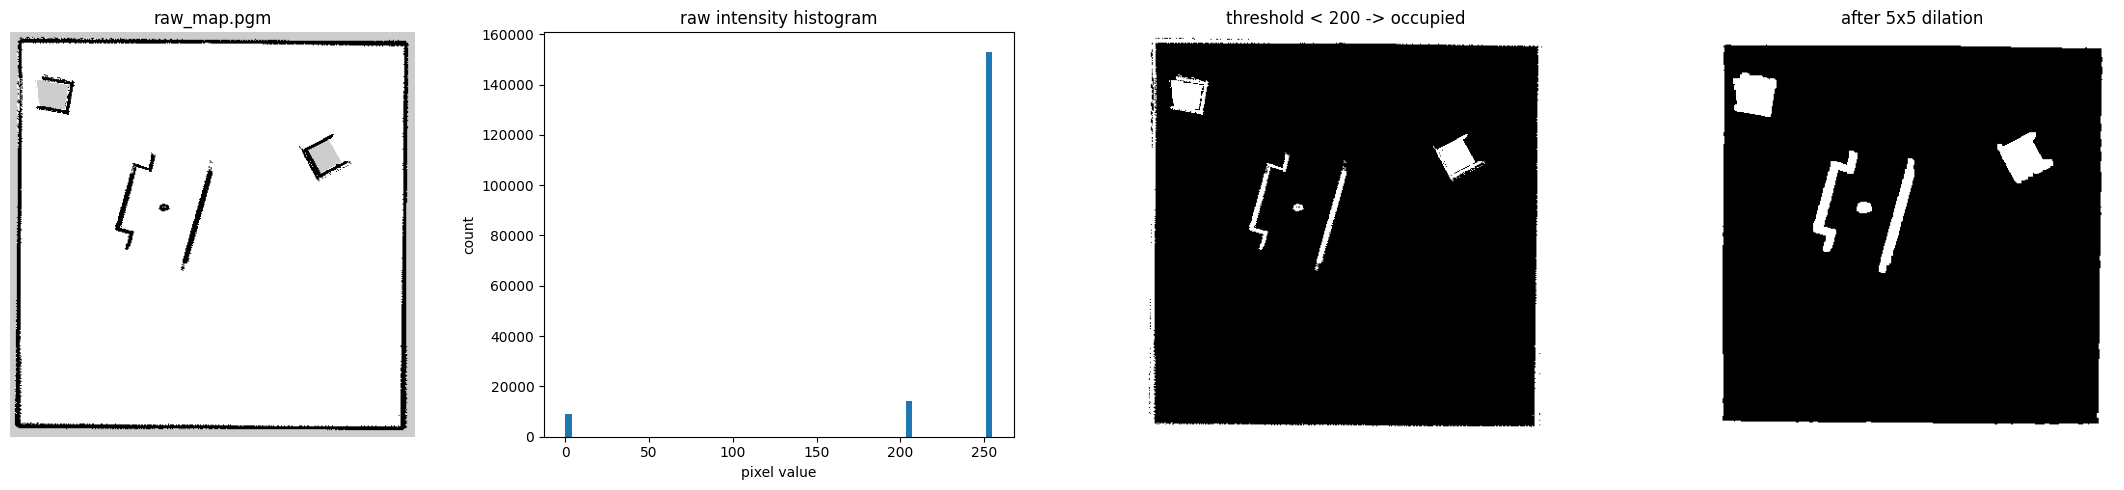

In [ ]:
raw_map = cv2.imread(str(RAW_MAP), cv2.IMREAD_GRAYSCALE)
if raw_map is None:
    raise FileNotFoundError(f'raw_map.pgm not found at {RAW_MAP}')

THRESHOLD = 230
_, binary_map = cv2.threshold(raw_map, THRESHOLD, 255, cv2.THRESH_BINARY_INV)

# Keep object matching sparse, but always use a dilated image for wall fitting.
# The wall is an arena-scale feature; without dilation, missing scan samples can
# make the square wall fit tilt or pick an equivalent 90-degree orientation.
object_map = binary_map.copy()
wall_map = cv2.dilate(binary_map, np.ones((5, 5), np.uint8))
dilated_map = object_map

print('raw_map shape:', raw_map.shape, 'min/max:', int(raw_map.min()), int(raw_map.max()))
print('binary occupied pixels:', int(np.count_nonzero(binary_map)))
print('object_map occupied pixels:', int(np.count_nonzero(object_map)))
print('wall_map occupied pixels:', int(np.count_nonzero(wall_map)))

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
show_img(raw_map, 'raw_map.pgm', vmin=0, vmax=255, ax=axes[0])
axes[1].hist(raw_map.ravel(), bins=64)
axes[1].set_title('raw intensity histogram')
axes[1].set_xlabel('pixel value')
axes[1].set_ylabel('count')
show_img(object_map, f'threshold < {THRESHOLD} -> occupied', vmin=0, vmax=255, ax=axes[2])
show_img(wall_map, 'wall_map: 5x5 dilation', vmin=0, vmax=255, ax=axes[3])
fig.tight_layout()

## 2. Template scaling sanity check

The templates are drawn at 1 mm/pixel and are resized to 10 mm/pixel. This makes the bridge scan template about 94 x 81 pixels and the pyramid scan template about 33 x 33 pixels. If the visible obstacle in the map is much larger or smaller than this, matching will fail.

bridge_lidar_scan.png    raw=(937, 807) scaled=(92, 79) nonzero=361
pyramid_lidar_scan.png   raw=(328, 328) scaled=(31, 31) nonzero=909
bridge_lidar_run.png     raw=(1, 1) scaled=None nonzero=0
pyramid_lidar_run.png    raw=(209, 209) scaled=(19, 19) nonzero=325
bridge_base.png          raw=(2020, 807) scaled=(200, 79) nonzero=13865
pyramid_base.png         raw=(624, 624) scaled=(60, 60) nonzero=3490


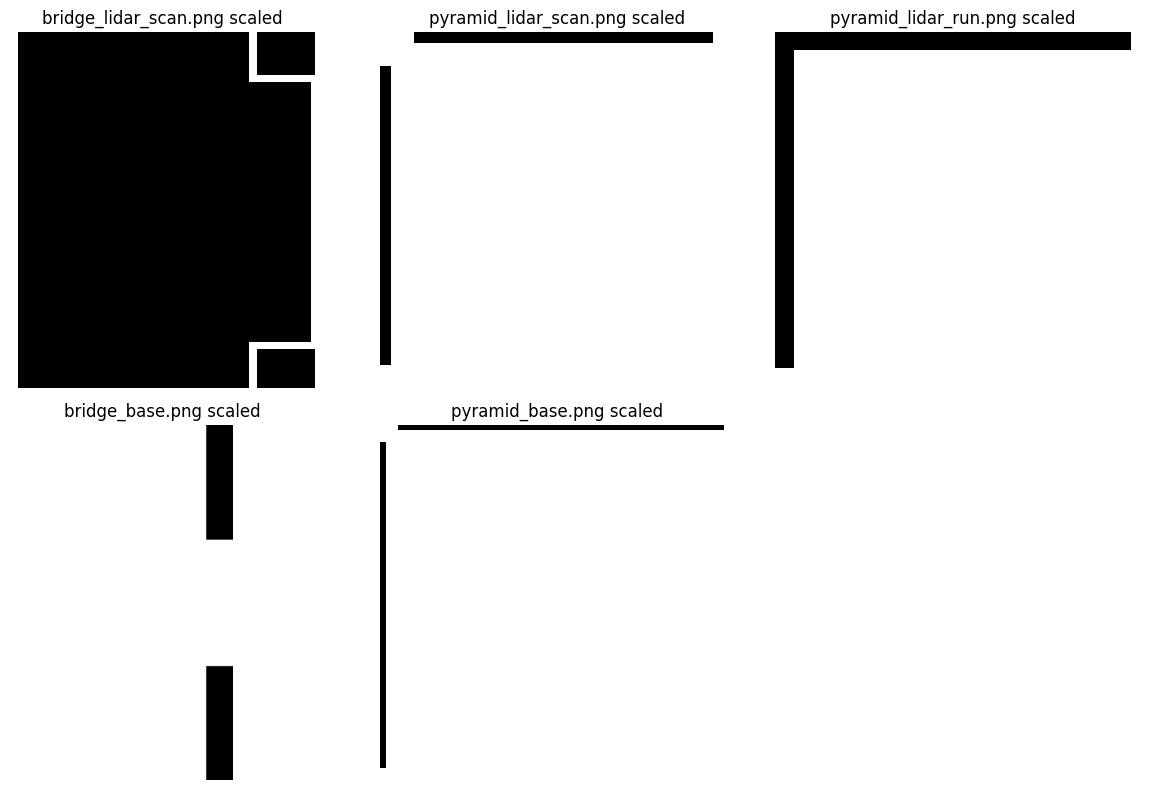

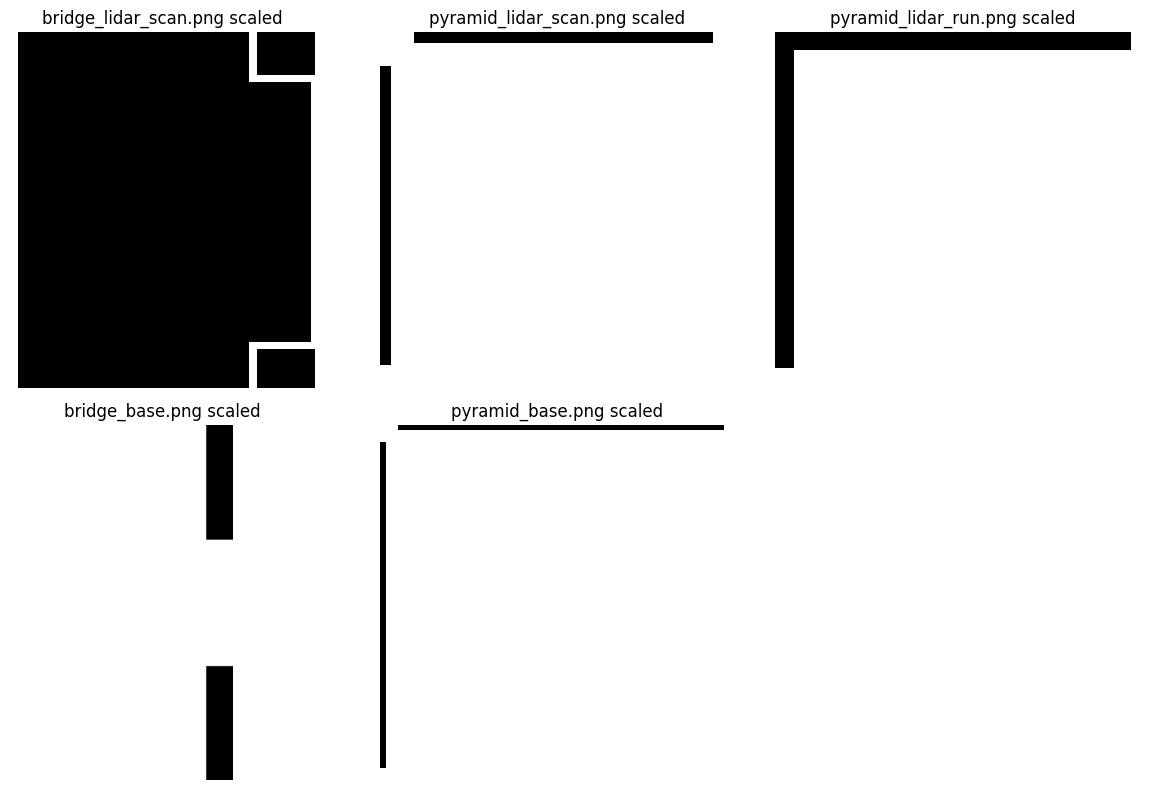

In [103]:
template_files = [
    'bridge_lidar_scan.png', 'pyramid_lidar_scan.png',
    'bridge_lidar_run.png', 'pyramid_lidar_run.png',
    'bridge_base.png', 'pyramid_base.png',
]

template_items = []
for name in template_files:
    raw = cv2.imread(str(TPL_DIR / name), cv2.IMREAD_GRAYSCALE)
    scaled = load_scaled_template(name, FINAL_RES)
    print(f'{name:24s} raw={None if raw is None else raw.shape} scaled={None if scaled is None else scaled.shape} nonzero={0 if scaled is None else int(np.count_nonzero(scaled))}')
    if scaled is not None:
        template_items.append((name + ' scaled', scaled, {'vmin': 0, 'vmax': 255}))

show_grid(template_items, cols=3, figsize_per=(4, 4))

## 3. Wall fit

The wall template is matched first to estimate arena center and yaw. The overlay should place the orange square border on top of the occupied arena boundary. If this is wrong, all later object matching is in the wrong coordinate frame.

Wall fit: center=(210,210) yaw=0 score=0.6522


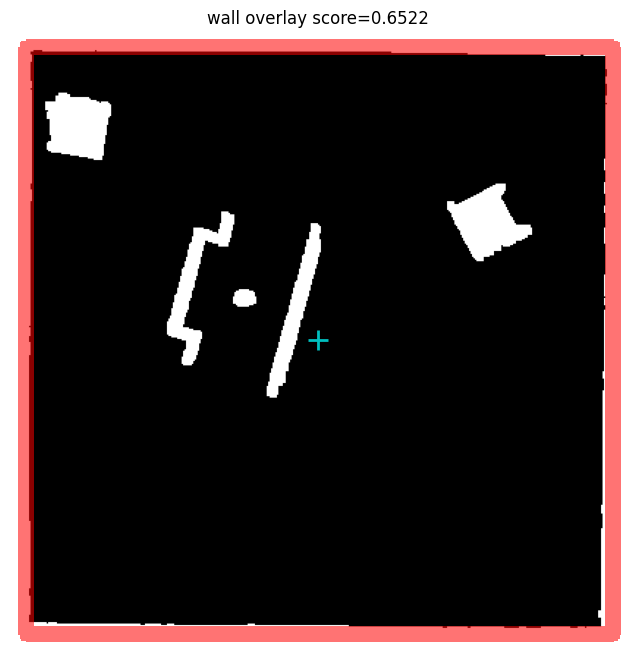

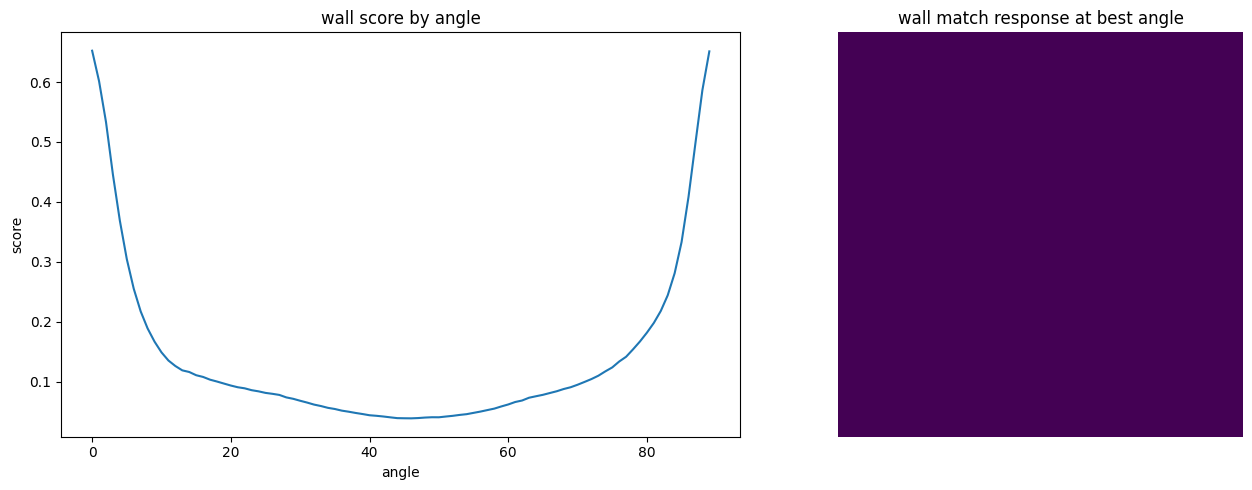

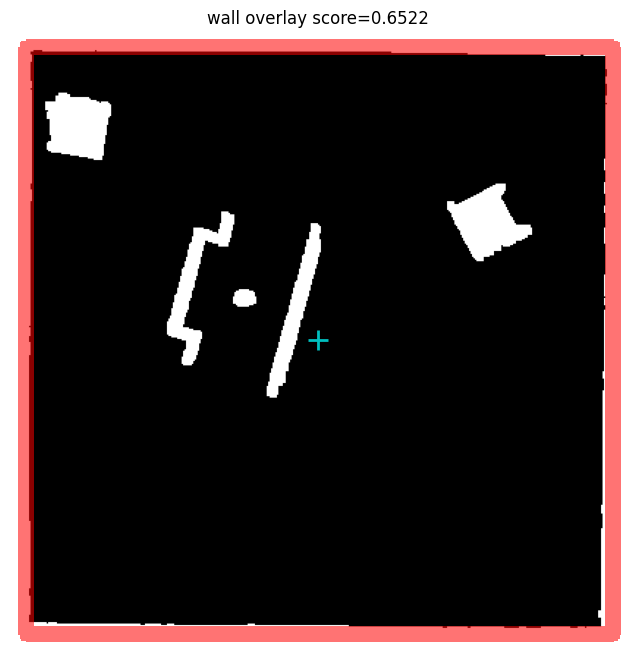

In [104]:
wall_tmp = create_wall_template()
wall_fit = fit_template_debug(wall_map, wall_tmp, range(0, 90, 1))
w_cx, w_cy, w_yaw, w_score = wall_fit['cx'], wall_fit['cy'], wall_fit['angle'], wall_fit['score']
# A square wall has 90-degree yaw symmetry. Normalize tiny numerical or fit
# differences into a stable arena yaw interval before alignment.
w_yaw = ((w_yaw + 45) % 90) - 45
wall_fit['rotated'] = rotate_template(wall_tmp, w_yaw)
print(f'Wall fit: center=({w_cx},{w_cy}) yaw={w_yaw} score={w_score:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(wall_fit['per_angle'][:, 0], wall_fit['per_angle'][:, 1])
axes[0].set_title('wall score by angle')
axes[0].set_xlabel('angle')
axes[0].set_ylabel('score')
show_img(wall_fit['response'], 'wall match response at best angle', cmap='viridis', ax=axes[1])
fig.tight_layout()

overlay_template(wall_map, wall_fit['rotated'], w_cx, w_cy, f'wall overlay score={w_score:.4f}')

## 4. Arena alignment

The processor rotates the binary map around the wall center by the fitted wall yaw. The red rectangle below is the 4 m x 4 m arena crop implied by `origin_x` and `origin_y`.

origin_x, origin_y: 10 410
arena crop x: 10 410 y: 10 410


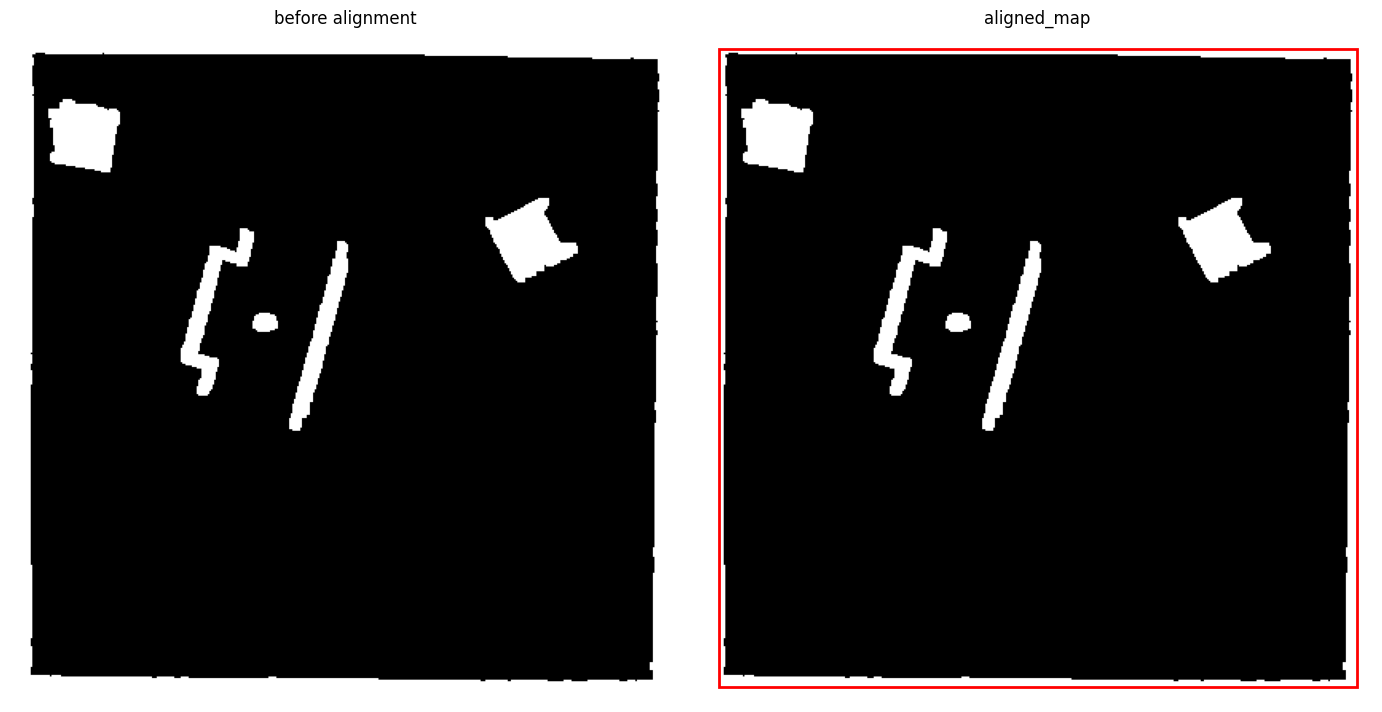

In [105]:
h_img, w_img = dilated_map.shape
M_align = cv2.getRotationMatrix2D((w_cx, w_cy), w_yaw, 1.0)
aligned_map = cv2.warpAffine(dilated_map, M_align, (w_img, h_img), flags=cv2.INTER_NEAREST)

half = (FIELD_SIZE / FINAL_RES) / 2
origin_x = int(w_cx - half)
origin_y = int(w_cy + half)
pixels = int(FIELD_SIZE / FINAL_RES)

print('origin_x, origin_y:', origin_x, origin_y)
print('arena crop x:', origin_x, origin_x + pixels, 'y:', origin_y - pixels, origin_y)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
show_img(dilated_map, 'before alignment', vmin=0, vmax=255, ax=axes[0])
show_img(aligned_map, 'aligned_map', vmin=0, vmax=255, ax=axes[1])
rect = plt.Rectangle((origin_x, origin_y - pixels), pixels, pixels, fill=False, edgecolor='red', linewidth=2)
axes[1].add_patch(rect)
fig.tight_layout()

## 5. Object matching debug

This runs the same object order as the script. For each object it shows: score by angle, the best response heatmap, the best rotated template, the overlay on the current search map, and the search map after masking the match.

Important checks:
- If the heatmap peak is on a wall or random clutter, the template is not distinctive enough after thresholding/dilation.
- If all scores are low, inspect template scale, polarity, and whether the raw map contains the object at lidar scan height.
- Matching `Pyramid_1` and `Pyramid_2` uses the same template twice, so the first mask must remove only the first pyramid footprint.

In [ ]:
objects = [
    ('Bridge', 'bridge_lidar_scan.png', 'bridge_lidar_run.png', 'bridge_base.png', range(0, 360, 2), np.round(np.arange(0.85, 1.55, 0.05), 2)),
    ('Pyramid_1', 'pyramid_lidar_scan.png', 'pyramid_lidar_run.png', 'pyramid_base.png', range(0, 360, 2), np.round(np.arange(0.85, 1.20, 0.05), 2)),
    ('Pyramid_2', 'pyramid_lidar_scan.png', 'pyramid_lidar_run.png', 'pyramid_base.png', range(0, 360, 2), np.round(np.arange(0.85, 1.20, 0.05), 2)),
]

planner_canvas = np.full((pixels, pixels), 255, dtype=np.uint8)
lidar_canvas = np.full((pixels, pixels), 255, dtype=np.uint8)
cv2.rectangle(planner_canvas, (0, 0), (pixels, pixels), 0, 2)
cv2.rectangle(lidar_canvas, (0, 0), (pixels, pixels), 0, 2)

landmarks = []
search_map = np.zeros_like(aligned_map)
wall_margin_px = int(round(0.20 / FINAL_RES))
sx1 = max(0, origin_x + wall_margin_px)
sx2 = min(aligned_map.shape[1], origin_x + pixels - wall_margin_px)
sy1 = max(0, origin_y - pixels + wall_margin_px)
sy2 = min(aligned_map.shape[0], origin_y - wall_margin_px)
search_map[sy1:sy2, sx1:sx2] = aligned_map[sy1:sy2, sx1:sx2]
fits = []

for name, scan_png, run_png, base_png, angles, scales in objects:
    scan_tmp = load_scaled_template(scan_png, FINAL_RES)
    run_tmp = load_scaled_template(run_png, FINAL_RES)
    base_tmp = load_scaled_template(base_png, FINAL_RES)
    if scan_tmp is None:
        print(f'{name}: scan template empty, skipping')
        continue

    is_pyramid = name.startswith('Pyramid')

    if is_pyramid:
        fit = detect_square_pyramid(search_map, scan_tmp)
        if fit is None:
            print(f'{name}: no square contour found in search map, skipping')
            continue
        cx, cy, oyaw, score = fit['cx'], fit['cy'], fit['angle'], fit['score']
        fits.append((name, fit))
        print(f'{name}: center=({cx},{cy}) yaw={oyaw:.1f} area_score={score:.4f}  [square contour detection]')

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        # Draw all square candidates on the search map for debugging
        cand_vis = cv2.cvtColor(search_map, cv2.COLOR_GRAY2BGR)
        for rank, (s, ccx, ccy, cangle, carea) in enumerate(fit['candidates'][:5]):
            color = (0, 255, 0) if rank == 0 else (0, 165, 255)
            cv2.circle(cand_vis, (int(round(ccx)), int(round(ccy))), 6, color, 2)
            cv2.putText(cand_vis, f'{s:.2f}', (int(round(ccx)) + 4, int(round(ccy)) - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)
        axes[0].imshow(cv2.cvtColor(cand_vis, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f'{name}: square candidates (green=best, orange=others)')
        axes[0].axis('off')
        show_img(fit['rotated'], f'{name} rotated template yaw={oyaw:.1f}°', vmin=0, vmax=255, ax=axes[1])
        fig.tight_layout()

    else:
        fit = fit_template_overlap_debug(search_map, scan_tmp, angles, scales=scales)
        if fit['rotated'] is None:
            print(f'{name}: no usable scale/angle trial, skipping')
            continue
        cx, cy, oyaw, score = fit['cx'], fit['cy'], fit['angle'], fit['score']
        fits.append((name, fit))
        print(f'{name}: center=({cx},{cy}) yaw={oyaw} scale={fit["scale"]:.2f} sparse_overlap={score:.4f}')

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        trials = fit['per_trial']
        for scale in np.unique(trials[:, 0]):
            s_trials = trials[trials[:, 0] == scale]
            axes[0].plot(s_trials[:, 1], s_trials[:, 2], alpha=0.35)
        best_by_scale = []
        for scale in np.unique(trials[:, 0]):
            s_trials = trials[trials[:, 0] == scale]
            best_by_scale.append((scale, s_trials[:, 2].max()))
        best_by_scale = np.array(best_by_scale)
        axes[0].plot(best_by_scale[:, 0] * 100, best_by_scale[:, 1], 'ko-', linewidth=2, label='best per scale x100')
        axes[0].legend(loc='best')
        axes[0].set_title(f'{name} sparse overlap by angle/scale')
        axes[0].set_xlabel('angle')
        axes[0].set_ylabel('overlap / template pixels')
        show_img(fit['response'], f'{name} response heatmap', cmap='viridis', ax=axes[1])
        show_img(fit['rotated'], f'{name} best rotated scan template', vmin=0, vmax=255, ax=axes[2])
        fig.tight_layout()

    overlay_template(search_map, fit['rotated'], cx, cy, f'{name} overlay score={score:.4f}')

    if score < 0.30:
        print(f'{name}: score below 0.30, still drawing for template-placement debug')

    erase_rotated_footprint(search_map, fit['rotated'], cx, cy, pad=6)

    mx = (cx - origin_x) * FINAL_RES
    my = (origin_y - cy) * FINAL_RES
    rel_yaw = oyaw % 360
    landmarks.append((name, mx, my, rel_yaw, score))

    px_x = int(mx / FINAL_RES)
    px_y = pixels - int(my / FINAL_RES)
    if name.startswith('Pyramid'):
        run_draw_tmp = clean_filled_template_like(run_tmp)
        base_draw_tmp = clean_filled_template_like(base_tmp)
    else:
        run_draw_tmp = run_tmp
        base_draw_tmp = base_tmp
    draw_on_map(lidar_canvas, run_draw_tmp, px_x, px_y, rel_yaw)
    draw_on_map(planner_canvas, base_draw_tmp, px_x, px_y, rel_yaw)

    fig, ax = plt.subplots(figsize=(8, 8))
    show_img(search_map, f'{name}: search map after mask', vmin=0, vmax=255, ax=ax)

print('\nlandmarks:')
for row in landmarks:
    print(row)


## 6. Match-method comparison

If the default `TM_CCOEFF_NORMED` score is misleading, compare it against other OpenCV methods for the same first-object search. This often exposes polarity or sparsity problems.

Bridge TM_CCOEFF_NORMED: center=(50,273) yaw=0 score=0.7050
Bridge TM_CCORR_NORMED: center=(50,273) yaw=0 score=0.7139
Bridge TM_SQDIFF_NORMED: center=(50,273) yaw=0 score=-0.6868


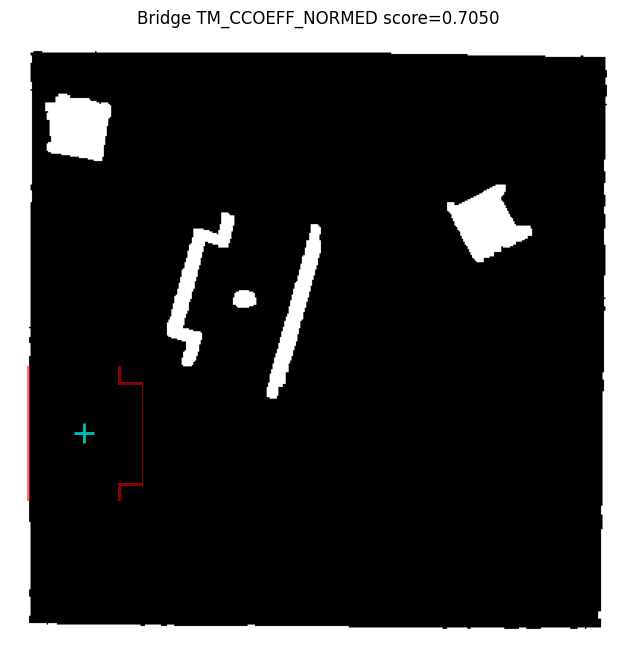

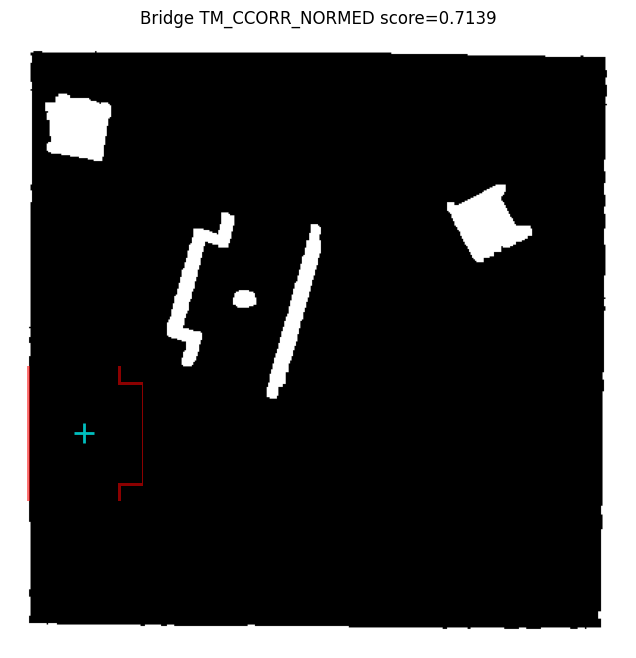

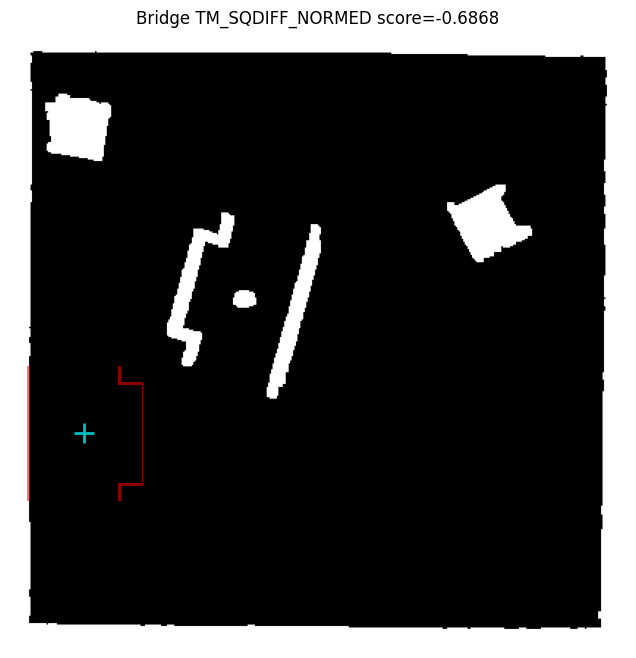

In [107]:
method_names = {
    'TM_CCOEFF_NORMED': cv2.TM_CCOEFF_NORMED,
    'TM_CCORR_NORMED': cv2.TM_CCORR_NORMED,
    'TM_SQDIFF_NORMED': cv2.TM_SQDIFF_NORMED,
}

test_name, test_scan, *_ = objects[0]
test_template = load_scaled_template(test_scan, FINAL_RES)

for method_name, method in method_names.items():
    fit = fit_template_debug(aligned_map, test_template, range(0, 360, 5), method=method)
    print(f'{test_name} {method_name}: center=({fit["cx"]},{fit["cy"]}) yaw={fit["angle"]} score={fit["score"]:.4f}')
    overlay_template(aligned_map, fit['rotated'], fit['cx'], fit['cy'], f'{test_name} {method_name} score={fit["score"]:.4f}')

## 6b. Obstacle-mask dot product

The script's binary map uses white pixels for occupied cells, but the PNG templates use black pixels for obstacle geometry on a white background. This cell inverts/crops the template into a white obstacle mask, then uses a simple normalized sliding dot product. The score is `overlap / template_obstacle_pixels`, so a score near 1 means the whole template obstacle shape landed on occupied map pixels.

This is usually a better first diagnostic than `TM_CCOEFF_NORMED` for sparse binary lidar maps.

Bridge obstacle mask shape=(92, 79) pixels=361
  dot product: center=(158,183) yaw=160 overlap=1.0000
Pyramid_1 obstacle mask shape=(31, 31) pixels=909
  dot product: center=(47,64) yaw=0 overlap=1.0000
Pyramid_2 obstacle mask shape=(31, 31) pixels=909
  dot product: center=(47,64) yaw=0 overlap=1.0000


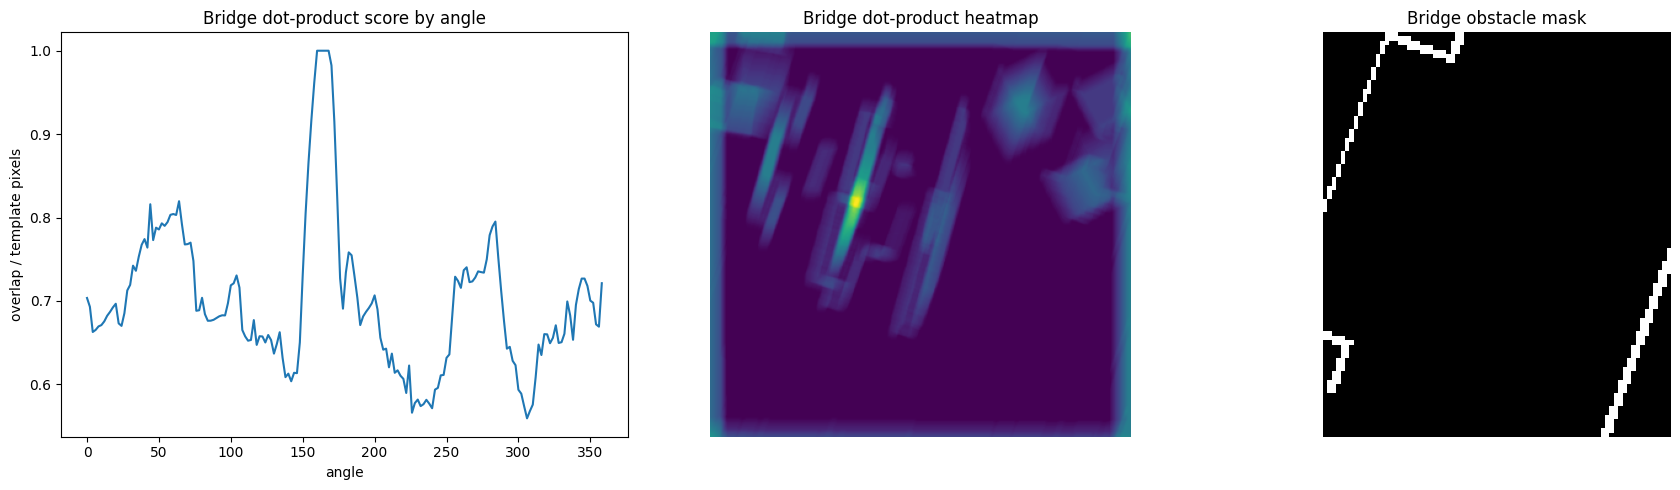

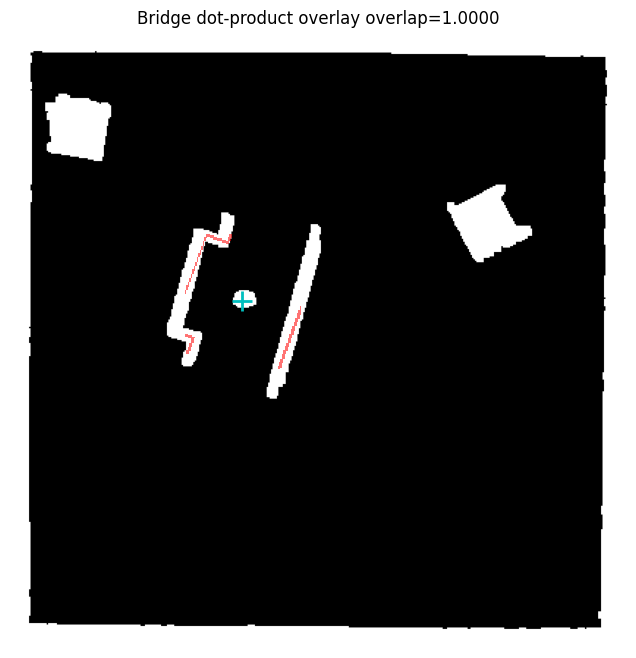

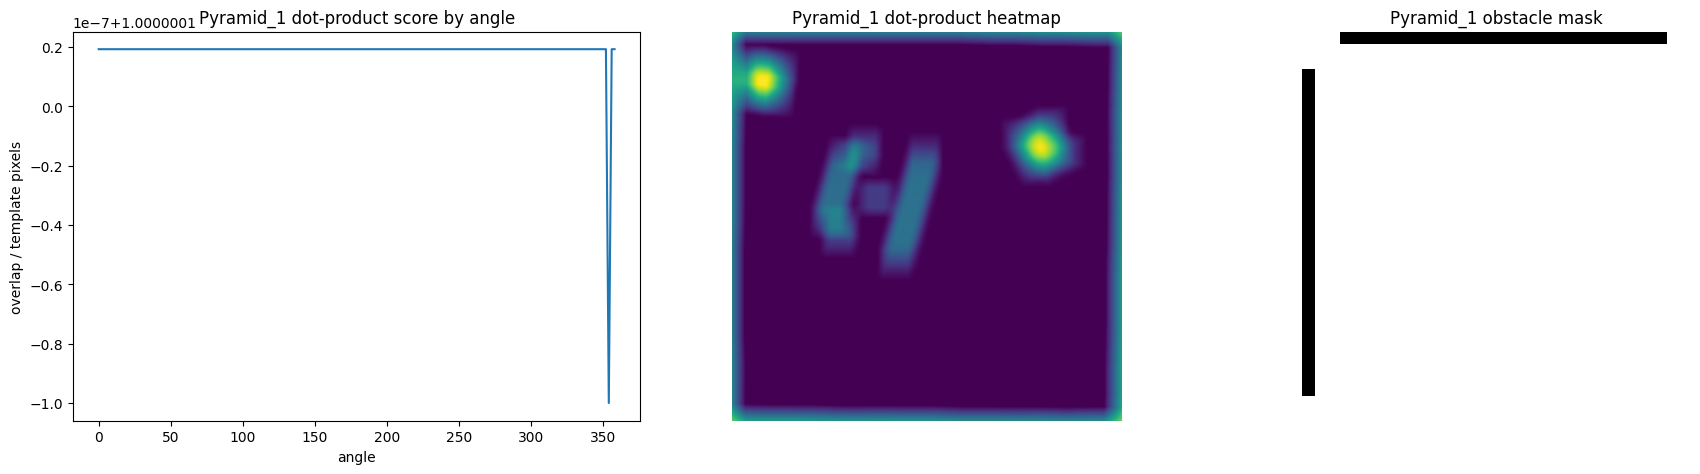

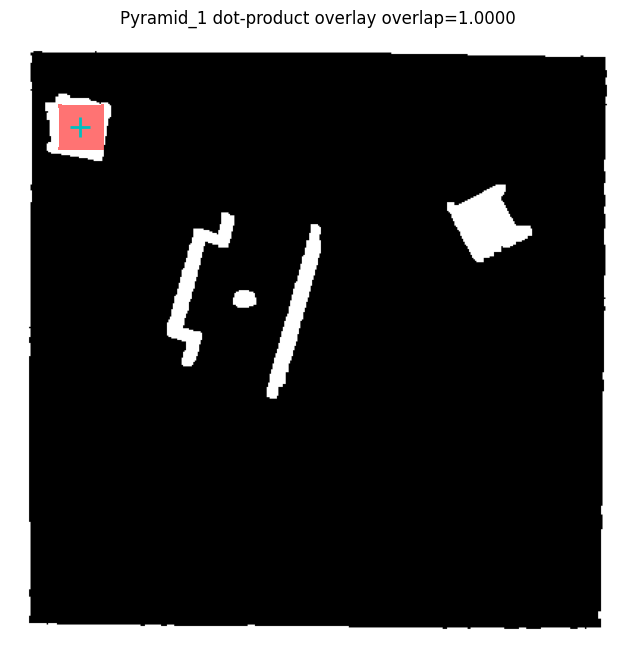

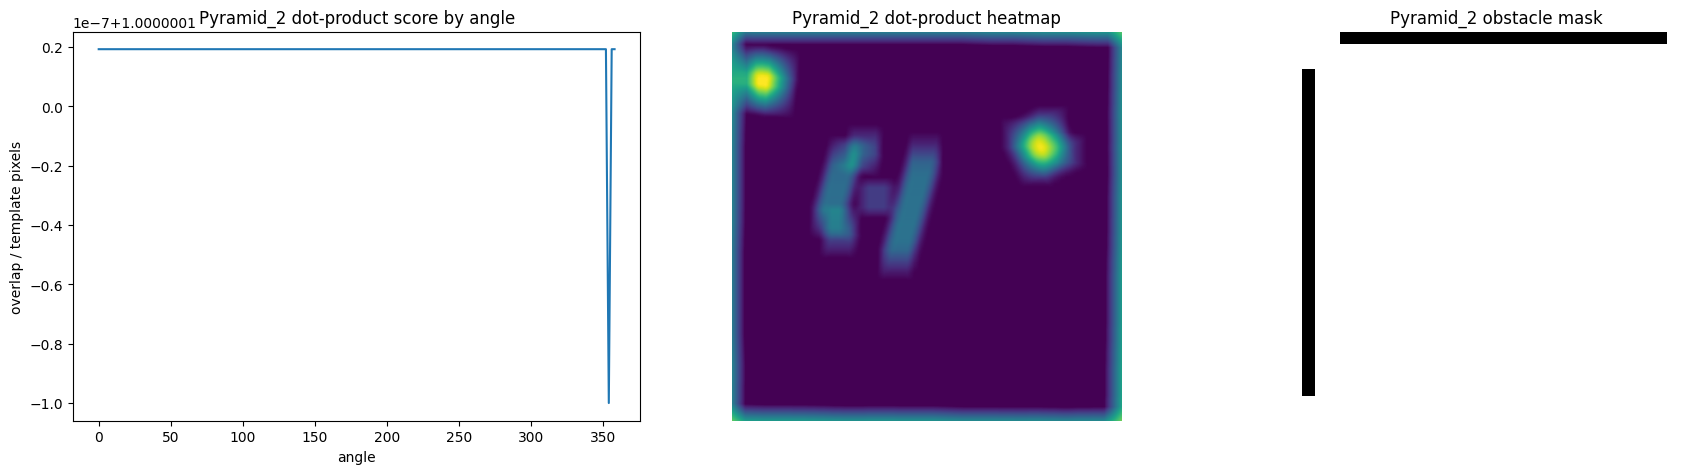

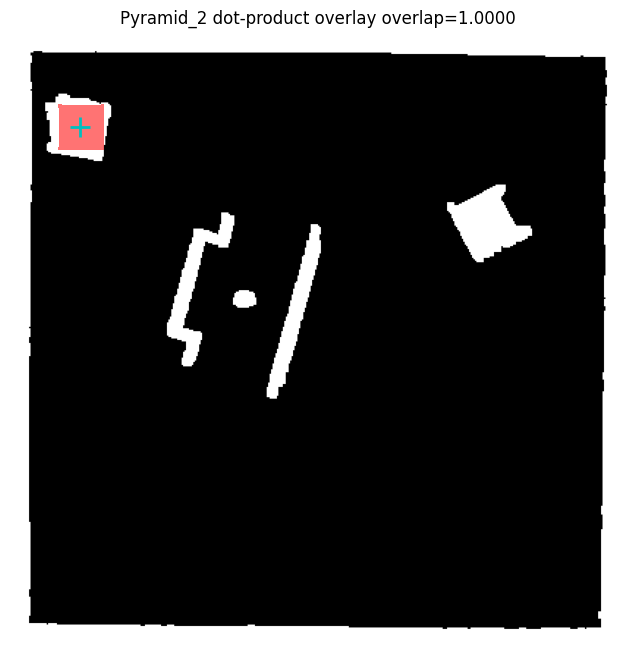

In [108]:
def load_obstacle_mask_template(filename, target_res, threshold=200, crop=True):
    raw = cv2.imread(str(TPL_DIR / filename), cv2.IMREAD_GRAYSCALE)
    if raw is None:
        raise FileNotFoundError(f'Missing template: {filename}')
    # PNG templates are black obstacle on white background. Convert to white obstacle.
    obstacle = np.where(raw < threshold, 255, 0).astype(np.uint8)
    if crop:
        ys, xs = np.where(obstacle > 0)
        if len(xs) == 0 or len(ys) == 0:
            return None
        obstacle = obstacle[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    scale = TPL_RES / target_res
    w = max(1, int(round(obstacle.shape[1] * scale)))
    h = max(1, int(round(obstacle.shape[0] * scale)))
    return cv2.resize(obstacle, (w, h), interpolation=cv2.INTER_NEAREST)


def dot_product_match_debug(map_img, template_mask, angles):
    map01 = (map_img > 0).astype(np.float32)
    best = {'score': -np.inf, 'loc': (0, 0), 'angle': None, 'rotated': None, 'response': None}
    per_angle = []
    for angle in angles:
        rotated_mask = rotate_template_bound(template_mask, angle)
        rotated = (rotated_mask > 0).astype(np.float32)
        denom = float(rotated.sum())
        if denom == 0:
            continue
        response = cv2.matchTemplate(map01, rotated, cv2.TM_CCORR) / denom
        _, max_val, _, max_loc = cv2.minMaxLoc(response)
        per_angle.append((angle, max_val))
        if max_val > best['score']:
            best.update(score=max_val, loc=max_loc, angle=angle, rotated=(rotated * 255).astype(np.uint8), response=response)
    h, w = best['rotated'].shape
    best['cx'] = best['loc'][0] + w // 2
    best['cy'] = best['loc'][1] + h // 2
    best['per_angle'] = np.array(per_angle, dtype=float)
    return best


for name, scan_png, *_ in objects:
    mask_tmp = load_obstacle_mask_template(scan_png, FINAL_RES)
    print(f'{name} obstacle mask shape={None if mask_tmp is None else mask_tmp.shape} pixels={0 if mask_tmp is None else int(np.count_nonzero(mask_tmp))}')
    if mask_tmp is None:
        continue
    fit = dot_product_match_debug(aligned_map, mask_tmp, range(0, 360, 2))
    print(f'  dot product: center=({fit["cx"]},{fit["cy"]}) yaw={fit["angle"]} overlap={fit["score"]:.4f}')
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(fit['per_angle'][:, 0], fit['per_angle'][:, 1])
    axes[0].set_title(f'{name} dot-product score by angle')
    axes[0].set_xlabel('angle')
    axes[0].set_ylabel('overlap / template pixels')
    show_img(fit['response'], f'{name} dot-product heatmap', cmap='viridis', ax=axes[1])
    show_img(fit['rotated'], f'{name} obstacle mask', vmin=0, vmax=255, ax=axes[2])
    fig.tight_layout()
    overlay_template(aligned_map, fit['rotated'], fit['cx'], fit['cy'], f'{name} dot-product overlay overlap={fit["score"]:.4f}')

## 7. Matched maps and template stamp sanity check

The first row shows maps drawn at the current matched positions. If matching returns a bad yaw or corner position, these can look clipped or rotated. The second row ignores matching and stamps all three templates at fixed visible positions with yaw 0. Lidar uses run-height templates only; the bridge run-height template is empty, so it should not appear on the lidar sanity canvas.

stamped Bridge: center=(120,210) yaw=0 run_shape=None base_shape=(200, 79)
stamped Pyramid_1: center=(300,110) yaw=0 run_shape=(19, 19) base_shape=(60, 60)
stamped Pyramid_2: center=(300,300) yaw=0 run_shape=(19, 19) base_shape=(60, 60)


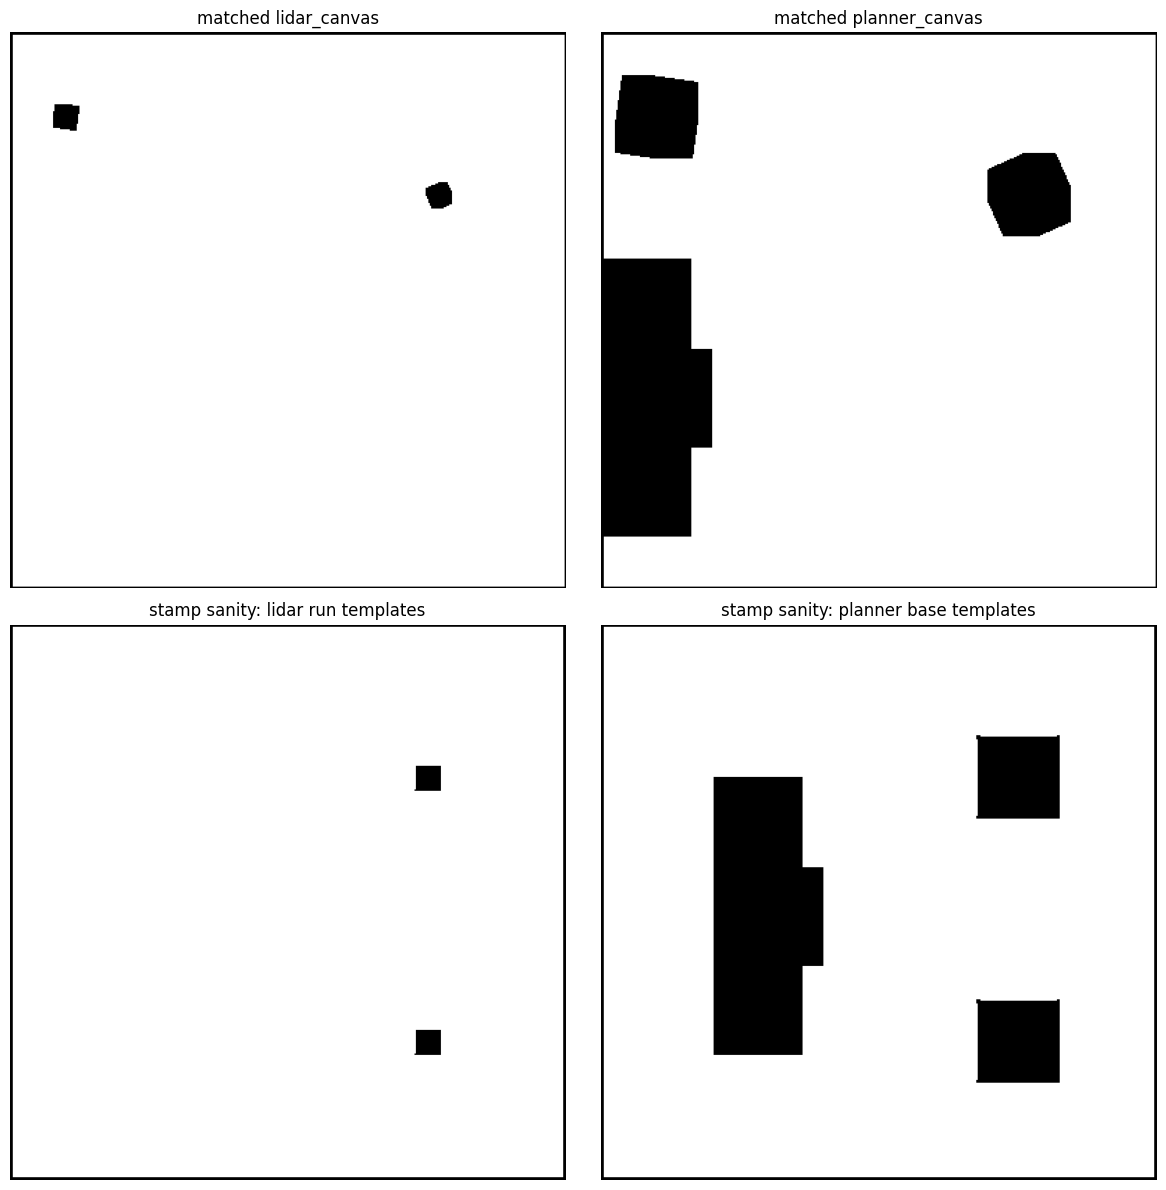

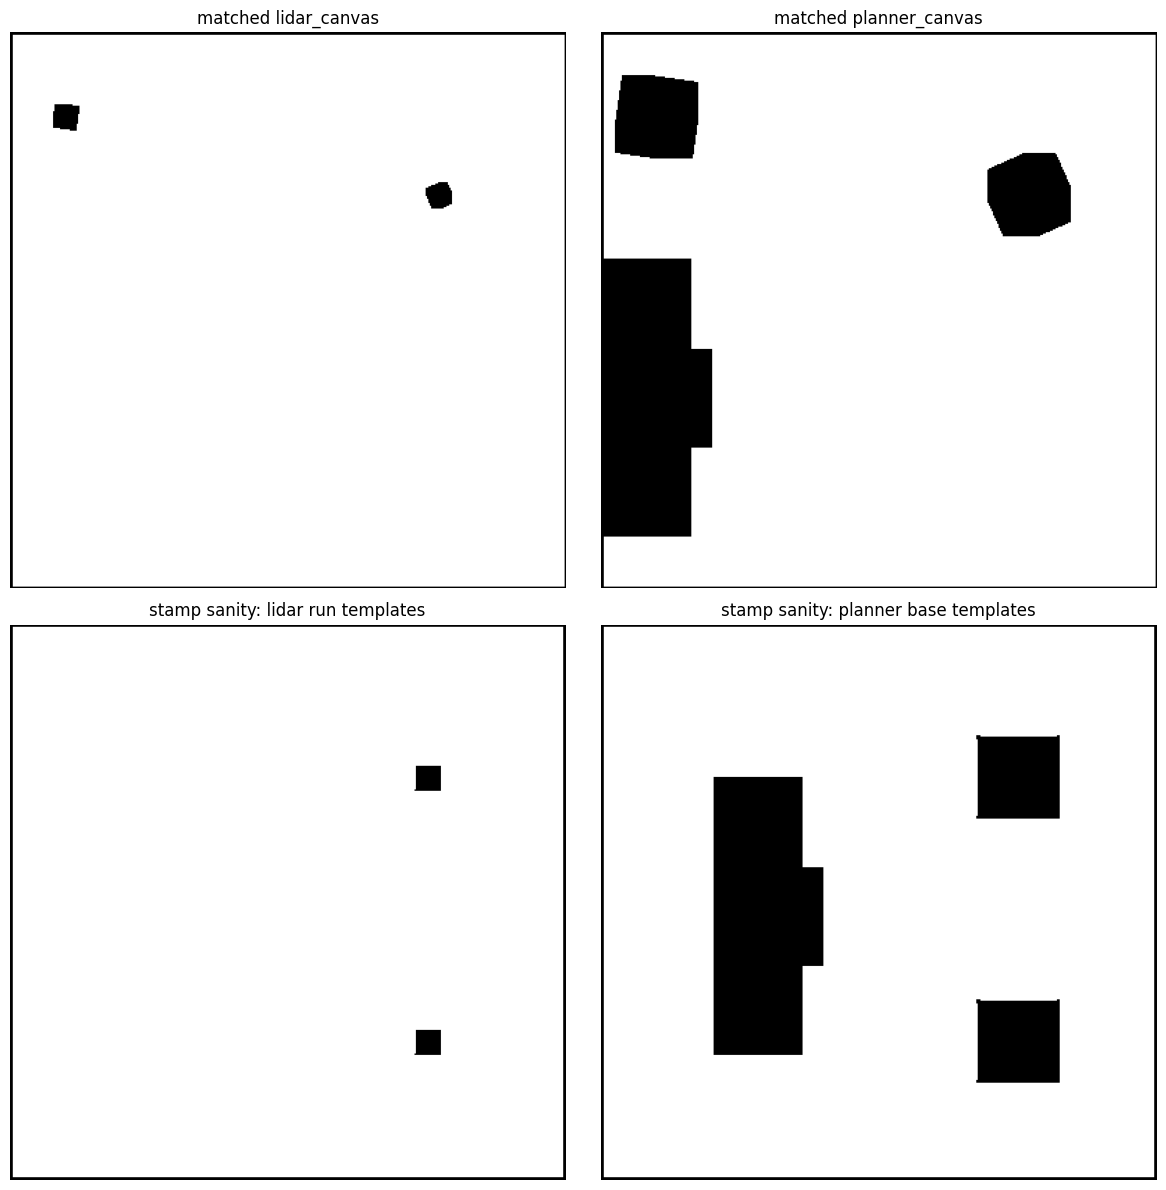

In [109]:
stamp_lidar_canvas = np.full((pixels, pixels), 255, dtype=np.uint8)
stamp_planner_canvas = np.full((pixels, pixels), 255, dtype=np.uint8)
cv2.rectangle(stamp_lidar_canvas, (0, 0), (pixels - 1, pixels - 1), 0, 2)
cv2.rectangle(stamp_planner_canvas, (0, 0), (pixels - 1, pixels - 1), 0, 2)

debug_positions = {
    'Bridge': (120, 210, 0),
    'Pyramid_1': (300, 110, 0),
    'Pyramid_2': (300, 300, 0),
}

for name, scan_png, run_png, base_png, _, _ in objects:
    run_tmp = load_scaled_template(run_png, FINAL_RES)
    base_tmp = load_scaled_template(base_png, FINAL_RES)
    px_x, px_y, yaw = debug_positions[name]
    if name.startswith('Pyramid'):
        run_tmp = clean_filled_template_like(run_tmp)
        base_tmp = clean_filled_template_like(base_tmp)
    draw_on_map(stamp_lidar_canvas, run_tmp, px_x, px_y, yaw)
    draw_on_map(stamp_planner_canvas, base_tmp, px_x, px_y, yaw)
    print(f'stamped {name}: center=({px_x},{px_y}) yaw={yaw} run_shape={None if run_tmp is None else run_tmp.shape} base_shape={None if base_tmp is None else base_tmp.shape}')

show_grid([
    ('matched lidar_canvas', lidar_canvas, {'vmin': 0, 'vmax': 255}),
    ('matched planner_canvas', planner_canvas, {'vmin': 0, 'vmax': 255}),
    ('stamp sanity: lidar run templates', stamp_lidar_canvas, {'vmin': 0, 'vmax': 255}),
    ('stamp sanity: planner base templates', stamp_planner_canvas, {'vmin': 0, 'vmax': 255}),
], cols=2, figsize_per=(6, 6))

## 8. Optional export

Uncomment and run this cell only when the notebook results look correct. It writes the same files as `map_processor.py`, plus match scores in the printed table above.

In [110]:
# export_rows = [(name, mx, my, yaw) for name, mx, my, yaw, score in landmarks]
# with open(MAP_DIR / 'landmarks.csv', 'w', newline='') as f:
#     writer = csv.writer(f)
#     writer.writerow(['Object_Type', 'X', 'Y', 'Yaw_Degrees'])
#     writer.writerows(export_rows)
#
# cv2.imwrite(str(MAP_DIR / 'planner_map.pgm'), planner_canvas)
# cv2.imwrite(str(MAP_DIR / 'lidar_map.pgm'), lidar_canvas)
#
# yaml_base = {'resolution': FINAL_RES, 'origin': [0.0, 0.0, 0.0],
#              'occupied_thresh': 0.65, 'free_thresh': 0.25, 'negate': 0}
# for out_name in ['planner_map', 'lidar_map']:
#     with open(MAP_DIR / f'{out_name}.yaml', 'w') as f:
#         yaml.dump({**yaml_base, 'image': f'{out_name}.pgm'}, f, default_flow_style=False)
#
# print('Exported notebook results to', MAP_DIR)